# Natural Language Processing with Disaster Tweets

Bu projede, Kaggle NLP Getting Started kapsamında verilen metin verileri kullanılarak bir doğal dil işleme (NLP) sınıflandırma problemi çözülmesi amaçlanmıştır. Amaç, tweet içeriklerine bakarak bir olayın gerçek bir afet olup olmadığını tahmin eden modeller geliştirmek ve farklı makine öğrenmesi ile derin öğrenme yöntemlerini karşılaştırmaktır.

In this project, a natural language processing (NLP) classification task was performed using the dataset from the Kaggle NLP Getting Started competition. The objective was to build models that can predict whether a tweet is related to a real disaster based on its content, and to compare machine learning and deep learning approaches.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/nlp-getting-started/sample_submission.csv
/kaggle/input/competitions/nlp-getting-started/train.csv
/kaggle/input/competitions/nlp-getting-started/test.csv


In [23]:
# =======================
# Standard Libraries
# =======================
import warnings
warnings.filterwarnings('ignore')

from collections import Counter

# =======================
# Data & Numerical
# =======================
import pandas as pd
import numpy as np

# =======================
# Visualization
# =======================
import matplotlib.pyplot as plt
import seaborn as sns

# =======================
# NLP Libraries
# =======================
import nltk
from nltk.corpus import stopwords
from textblob import TextBlob
import re

# =======================
# Scikit-learn (ML)
# =======================

# Model Selection
from sklearn.model_selection import train_test_split

# Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.svm import LinearSVC

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# =======================
# Deep Learning (TensorFlow)
# =======================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.layers import BatchNormalization

In [3]:
train = pd.read_csv('/kaggle/input/competitions/nlp-getting-started/train.csv')
test = pd.read_csv('/kaggle/input/competitions/nlp-getting-started/test.csv')

In [4]:
train.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [5]:
test.head()

,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan


In [6]:
train.isnull().sum()

id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

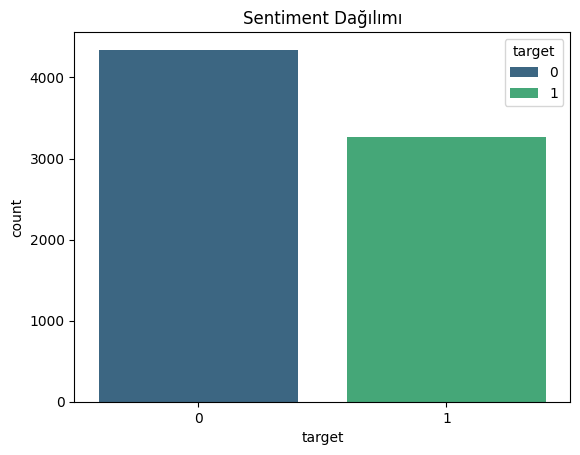

In [8]:
# Sentiment Distribution
sns.countplot(x=train['target'], hue=train['target'], palette='viridis')
plt.title("Sentiment Dağılımı")
plt.show()

In [10]:
#Cleaning
def clean_text(df, col='text'):
    df[col] = df[col].str.lower()                              # küçük harf
    df[col] = df[col].str.replace('<.*?>', '', regex=True)     # HTML tagları (<br/>)
    df[col] = df[col].str.replace('[^\w\s]', '', regex=True)   # noktalama
    df[col] = df[col].str.replace('\d+', '', regex=True)       # rakamlar
    df[col] = df[col].str.replace('\n', '', regex=True)        # satır sonu
    df[col] = df[col].str.replace('\r', '', regex=True)        # enter
    return df

train = clean_text(train)
test  = clean_text(test)

In [12]:
train['text'][0]

'our deeds are the reason of this earthquake may allah forgive us all'

In [13]:
#Stopwords + Lemmatization
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def ekkok(text):
    words = TextBlob(text).words
    return [word.lemmatize() for word in words if word.lower() not in stop_words]

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [14]:
#Vectorization
x_train = train['text']
y_train = train['target']

x_test = test['text']


vect = CountVectorizer(ngram_range=(1, 2), analyzer=ekkok, stop_words='english')
x_train = vect.fit_transform(x_train)
x_test  = vect.transform(x_test)

In [15]:
print("Train shape:", x_train.shape)

Train shape: (7613, 20589)


In [16]:
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train  
)

In [19]:
ml_models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, C=1.0),
    'LinearSVC'           : LinearSVC(max_iter=1000),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
}

ml_results = {}

for name, m in ml_models.items():
    m.fit(x_train, y_train)
    pred = m.predict(x_val)
    acc  = accuracy_score(y_val, pred)
    ml_results[name] = acc
    
    print(f"✅ {name}: {acc:.4f}")

✅ Logistic Regression: 0.8142
✅ LinearSVC: 0.7807
✅ Random Forest: 0.7984


In [20]:
best_ml_name  = max(ml_results, key=ml_results.get)
best_ml_score = ml_results[best_ml_name]
best_ml_model = ml_models[best_ml_name]

print(f"En iyi ML: {best_ml_name} → {best_ml_score:.4f}")

En iyi ML: Logistic Regression → 0.8142


## Deep Learning Model

In [21]:
x_train = x_train.toarray()
x_val = x_val.toarray()

input_dim = x_train.shape[1]

In [24]:
dl_model = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

2026-04-23 12:43:01.583981: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [25]:
dl_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [26]:
dl_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │     2,635,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,644,609 (10.09 MB)

 Trainable params: 2,644,225 (10.09 MB)

 Non-trainable params: 384 (1.50 KB)

In [27]:
callbacks = [EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]

In [28]:
history = dl_model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.6296 - loss: 0.7239 - val_accuracy: 0.7347 - val_loss: 0.6018
Epoch 2/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.8854 - loss: 0.2916 - val_accuracy: 0.7997 - val_loss: 0.4670
Epoch 3/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9492 - loss: 0.1444 - val_accuracy: 0.7938 - val_loss: 0.5283
Epoch 4/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9698 - loss: 0.0912 - val_accuracy: 0.7919 - val_loss: 0.6294
Epoch 5/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.9737 - loss: 0.0788 - val_accuracy: 0.7919 - val_loss: 0.6970


In [29]:
# DL accuracy
dl_pred_prob = dl_model.predict(x_val)
dl_pred      = (dl_pred_prob > 0.5).astype(int).flatten()
dl_acc       = accuracy_score(y_val, dl_pred)

print(f"Deep Learning Accuracy: {dl_acc:.4f}")

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Deep Learning Accuracy: 0.7997


In [30]:
final_pred = best_ml_model.predict(x_test)

In [31]:
# Submission
submission = pd.DataFrame({
    'id'    : test['id'],         
    'target': final_pred.astype(int)
})

In [32]:
submission.head(10)

,id,target
0,0,1
1,2,1
2,3,1
3,9,1
4,11,1
5,12,1
6,21,0
7,22,0
8,27,0
9,29,0


In [33]:
submission.to_csv('submission.csv', index=False)

Elde edilen sonuçlara göre, Logistic Regression modeli yaklaşık %81.4 doğruluk ile en iyi performansı göstermiştir. Random Forest (%79.8) ve LinearSVC (%78.1) modelleri biraz daha düşük performans sergilemiştir. Kurulan derin öğrenme modeli ise yaklaşık %78.5 doğruluk elde etmiş, ancak klasik makine öğrenmesi modelini geçememiştir. Bu sonuçlar, özellikle metin verilerinde uygun özellik çıkarımı (feature engineering) ile lineer modellerin oldukça güçlü performans gösterebildiğini ortaya koymaktadır.

According to the results, Logistic Regression achieved the best performance with approximately 81.4% accuracy. Random Forest (79.8%) and LinearSVC (78.1%) followed with slightly lower performance. The deep learning model reached about 78.5% accuracy but did not outperform the classical machine learning approaches. Overall, the results show that linear models can be highly effective for text classification tasks when combined with proper feature engineering.